# Phase 2 — gene normalization & panel scoring

Demonstrates the two new modules added in Phase 2:
- **`genes.normalize_symbol`** — resolves raw marker symbols to official ZFIN names, handling aliases, superseded names, and *a*/*b* paralogs.
- **`panels.score_markers`** — produces a ranked bucket table via rank-weighted overlap against the curated `panels.yaml`.

Phase 1 built the raw data loaders (ZFA graph, ZFIN expression, GAF synonyms). Phase 2 consumes those outputs to turn a raw marker list into a ranked table of broad tissue/lineage candidates — the first two steps of the annotation loop. Phase 3 will ground the top candidates with ZFIN in-vivo expression and make a final labeling decision.

<div class="alert alert-warning" role="alert">
    <b>⚙️ Prerequisite — run before this notebook</b>
    <br><br>
    <b>1.</b> From the repo root: <code>bash scripts/setup_data.sh</code> &nbsp;(downloads ontology files into <code>data/ontologies/</code>)
    <br>
    <b>2.</b> Start the server with <code>make notebook</code> &nbsp;(keeps the working directory at the repo root)
</div>

In [1]:
import math
import os
from pathlib import Path

import zlabel; print(f"zlabel {zlabel.__version__}")

PACKAGE = "zlabel"
ROOT_DIR = Path(os.getcwd().split(PACKAGE, 1)[0]) / PACKAGE
DATA_DIR = ROOT_DIR / "data/ontologies"
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Data not found at {DATA_DIR.resolve()}.  Run: bash scripts/setup_data.sh"
    )

# The GAF synonym map from Phase 1 is now consumed by normalize_symbol.
syn = zlabel.load_gene_synonym_map(DATA_DIR / "zfin.gaf")
print(f"Synonym map: {len(syn):,} entries")

# panels.yaml is bundled with the package.  __file__ locates it correctly
# whether the package is installed editably (uv) or from a built wheel.
panels_path = Path(zlabel.__file__).parent / "panels.yaml"
panels = zlabel.load_panels(panels_path)
identity = [p for p in panels if p.kind == zlabel.KIND_IDENTITY]
state    = [p for p in panels if p.kind == zlabel.KIND_STATE]
print(f"Panels loaded: {len(identity)} identity, {len(state)} state  ({len(panels)} total)")

zlabel 0.1.0
Synonym map: 66,682 entries
Panels loaded: 12 identity, 2 state  (14 total)


## 1. Gene normalization

Published zebrafish datasets regularly use aliases, previous names, or species-ambiguous symbols — a valid marker can be missed entirely if normalization is skipped. `normalize_symbol` looks up the lowercased input in the GAF synonym map and returns one of three outcomes:

| Status | Meaning |
|---|---|
| **resolved** | exactly one current ZFIN symbol found |
| **ambiguous** | one previous name maps to several current paralogs (*a*/*b* duplication) |
| **unresolved** | not found in the GAF at all |

Only **resolved** markers enter the panel scorer. Ambiguous and unresolved markers are excluded from *both* numerator and denominator so the labeler never guesses on an uncertain symbol.

In [2]:
# Four representative inputs covering every outcome.
cases = [
    ("kdrl",     "current symbol — resolves to itself"),
    ("flk1",     "alias for kdrl"),
    ("gata1",    "previous name for gata1a"),
    ("kdr",      "shared alias for both kdr and kdrl (two VEGFR paralogs) — ambiguous"),
    ("notareal", "not in the ZFIN GAF — unresolved"),
]

print(f"{'Input':<12}  {'Status':<10}  {'Resolved to':<25}  Note")
print("-" * 82)
for symbol, note in cases:
    r = zlabel.normalize_symbol(symbol, syn)
    resolved_to = ", ".join(sorted(r.symbols)) if r.symbols else "—"
    print(f"{symbol:<12}  [{r.status:<10}]  {resolved_to:<25}  {note}")

Input         Status      Resolved to                Note
----------------------------------------------------------------------------------
kdrl          [resolved  ]  kdrl                       current symbol — resolves to itself
flk1          [resolved  ]  kdrl                       alias for kdrl
gata1         [resolved  ]  gata1a                     previous name for gata1a
kdr           [ambiguous ]  kdr, kdrl                  shared alias for both kdr and kdrl (two VEGFR paralogs) — ambiguous
notareal      [unresolved]  —                          not in the ZFIN GAF — unresolved


In [3]:
# normalize_markers applies normalize_symbol to a full ranked list in order.
# The keystone muscle-cluster marker list used throughout this notebook.
MARKERS = ["mylz2", "acta1b", "tnnt3a", "myod1", "myog", "hbae1.1", "kdrl"]

results = zlabel.normalize_markers(MARKERS, syn)

print(f"{'Rank':<5}  {'Input':<10}  {'Status':<10}  Resolved to")
print("-" * 50)
for rank, r in enumerate(results, start=1):
    resolved_to = ", ".join(sorted(r.symbols)) if r.symbols else "—"
    print(f"{rank:<5}  {r.input:<10}  [{r.status:<10}]  {resolved_to}")

Rank   Input       Status      Resolved to
--------------------------------------------------
1      mylz2       [resolved  ]  mylpfa
2      acta1b      [resolved  ]  acta1b
3      tnnt3a      [resolved  ]  tnnt3a
4      myod1       [resolved  ]  myod1
5      myog        [resolved  ]  myog
6      hbae1.1     [resolved  ]  hbae1.1
7      kdrl        [resolved  ]  kdrl


## 2. The panel dictionary

`panels.yaml` is the domain-knowledge file: all marker curation lives there, not in code. Each top-level entry is a **bucket** — a broad tissue, lineage, or transcriptional-state call — with its marker set cited back to a source.

Two kinds of buckets:
- **identity** — a cell-type lineage (neural, muscle, blood, …). Carries `germ_layer`, `tissue`, and `lineage` metadata.
- **state** — a transcriptional program orthogonal to identity (cycling, stress, …). `germ_layer`, `tissue`, and `lineage` are empty; a cluster can be both *muscle* and *cycling*.

Identity buckets can carry optional **subpanels** — named subsets for finer resolution on subclusters (e.g. `muscle.fast`, `muscle.slow`). They load in Phase 2 but are not scored here; Phase 3 uses them.

In [4]:
# Summary of every loaded panel.
print(f"{'Bucket':<22}  {'Kind':<8}  {'Germ layer':<18}  {'Markers':>7}  {'Subpanels'}")
print("-" * 75)
for p in sorted(panels, key=lambda p: (p.kind, p.bucket)):
    sub = list(p.subpanels) or "—"
    sub_str = ", ".join(sub) if isinstance(sub, list) else sub
    gl = p.germ_layer if p.germ_layer else "—"
    print(f"{p.bucket:<22}  {p.kind:<8}  {gl:<18}  {len(p.markers):>7}  {sub_str}")

print()
muscle = next(p for p in panels if p.bucket == "muscle")
print(f"muscle markers ({len(muscle.markers)}): {', '.join(sorted(muscle.markers))}")

Bucket                  Kind      Germ layer          Markers  Subpanels
---------------------------------------------------------------------------
blood_erythroid         identity  mesoderm                  6  —
cartilage               identity  neural crest              6  —
endoderm_gut            identity  endoderm                  6  —
endothelium             identity  mesoderm                  6  —
epidermis               identity  ectoderm                  5  —
germline                identity  germline                  4  —
immune_myeloid          identity  mesoderm                  7  —
mesenchyme              identity  mesoderm                  7  —
muscle                  identity  mesoderm                  9  fast, slow, cardiac, myoblast
neural                  identity  ectoderm                  8  —
notochord               identity  mesoderm                  5  —
pigment                 identity  neural crest              6  —
cycling                 state     —        

## 3. Rank-weighted scoring

The scorer uses **rank-weighted overlap**: a marker at rank *r* (1-based, most significant = rank 1) contributes weight *w(r) = 1 / log₂(r + 1)*. The denominator is the total weight of all **resolved** markers, whether or not they hit any panel.

```
score(bucket) = Σ w(r) for resolved markers hitting this bucket
               ─────────────────────────────────────────────────
               Σ w(r) for all resolved markers
```

This has two useful properties:
- Top markers drive the score (rank 1 weighs 1.0; the tail decays but is never discarded).
- A cluster with mostly off-panel markers scores all buckets low — Phase 3 can abstain honestly.

All panels are always returned (even at score 0.0), sorted descending by score.

In [5]:
# Rank-weight decay table for the 7-marker list.
print("w(r) = 1 / log2(r + 1)\n")
print(f"{'Rank':>4}  {'Weight':>8}  {'Cumulative':>10}  Marker (from keystone list)")
print("-" * 55)
running = 0.0
for r, m in enumerate(MARKERS, start=1):
    w = 1.0 / math.log2(r + 1)
    running += w
    print(f"{r:>4}  {w:>8.4f}  {running:>10.4f}  {m}")

w(r) = 1 / log2(r + 1)

Rank    Weight  Cumulative  Marker (from keystone list)
-------------------------------------------------------
   1    1.0000      1.0000  mylz2
   2    0.6309      1.6309  acta1b
   3    0.5000      2.1309  tnnt3a
   4    0.4307      2.5616  myod1
   5    0.3869      2.9485  myog
   6    0.3562      3.3047  hbae1.1
   7    0.3333      3.6380  kdrl


In [6]:
# Score the keystone 7-marker muscle cluster against the full panel dictionary.
scores = zlabel.score_markers(MARKERS, panels, syn)

print(f"Input: {MARKERS}\n")
print(f"{'#':<3}  {'Bucket':<22}  {'Score':>6}  {'Kind':<8}  Matched (rank)")
print("-" * 80)
for i, s in enumerate(scores):
    matched = ", ".join(f"{m.input}(r{m.rank})" for m in s.matched_markers) or "—"
    print(f"{i + 1:<3}  {s.bucket:<22}  {s.score:>6.4f}  {s.kind:<8}  {matched}")

top = scores[0]
runners_up_identity = [s for s in scores[1:] if s.kind == zlabel.KIND_IDENTITY and s.score > 0]
print()
print(f"Top bucket: {top.bucket!r}  score {top.score:.4f}")
if runners_up_identity:
    second = runners_up_identity[0]
    print(f"Dominance over next identity bucket ({second.bucket}): {top.score / second.score:.1f}x")

Input: ['mylz2', 'acta1b', 'tnnt3a', 'myod1', 'myog', 'hbae1.1', 'kdrl']

#    Bucket                   Score  Kind      Matched (rank)
--------------------------------------------------------------------------------
1    muscle                  0.8105  identity  mylz2(r1), acta1b(r2), tnnt3a(r3), myod1(r4), myog(r5)
2    blood_erythroid         0.0979  identity  hbae1.1(r6)
3    endothelium             0.0916  identity  kdrl(r7)
4    cartilage               0.0000  identity  —
5    cycling                 0.0000  state     —
6    endoderm_gut            0.0000  identity  —
7    epidermis               0.0000  identity  —
8    germline                0.0000  identity  —
9    immune_myeloid          0.0000  identity  —
10   mesenchyme              0.0000  identity  —
11   neural                  0.0000  identity  —
12   notochord               0.0000  identity  —
13   pigment                 0.0000  identity  —
14   stress_heatshock        0.0000  state     —

Top bucket: 'muscle'  scor

## 4. Ambiguous markers — excluded from scoring

When the teleost genome duplication leaves both paralogs sharing an old name, the resolver marks the input as **ambiguous** and excludes it from *both* numerator and denominator. This is intentional: scoring would require picking one paralog, which the labeler should not do silently.

The consequence is that the denominator contracts (total weight is smaller), so the remaining markers carry proportionally more weight. A cluster whose top marker is ambiguous still gets a meaningful score from its other resolved markers — it does not collapse to zero.

In [7]:
# kdr is a shared alias for both kdr (flt1-like) and kdrl (vegfr2) — ambiguous in the real GAF.
result = zlabel.normalize_symbol("kdr", syn)
print(f"normalize_symbol('kdr'): [{result.status}] — {result.note}")
print()

# Two-marker list: myod1 (resolved, rank 1 — muscle) + kdr (ambiguous, excluded).
# Only myod1 enters the denominator; muscle scores 1.0 exactly.
ambig_markers = ["myod1", "kdr"]
scores_ambig = zlabel.score_markers(ambig_markers, panels, syn)

print(f"Input: {ambig_markers}")
print(f"Resolved for scoring: myod1 only  (kdr is ambiguous — excluded from both numerator and denominator)")
print()
for s in scores_ambig:
    if s.score > 0:
        matched = ", ".join(m.input for m in s.matched_markers)
        print(f"  {s.bucket:<22}  score {s.score:.4f}  matched: {matched}")

print()
# Compare: with the resolved paralog supplied directly, it scores normally.
resolved_markers = ["myod1", "kdrl"]
scores_resolved = zlabel.score_markers(resolved_markers, panels, syn)
print(f"With 'kdrl' (one resolved paralog) instead of 'kdr':")
for s in scores_resolved:
    if s.score > 0:
        matched = ", ".join(m.input for m in s.matched_markers)
        print(f"  {s.bucket:<22}  score {s.score:.4f}  matched: {matched}")

normalize_symbol('kdr'): [ambiguous] — maps to 2 current paralogs: kdr, kdrl

Input: ['myod1', 'kdr']
Resolved for scoring: myod1 only  (kdr is ambiguous — excluded from both numerator and denominator)

  muscle                  score 1.0000  matched: myod1

With 'kdrl' (one resolved paralog) instead of 'kdr':
  muscle                  score 0.6131  matched: myod1
  endothelium             score 0.3869  matched: kdrl


## What's next

**Phase 3** wires the scored bucket table to the two remaining evidence signals:
- **ZFIN in-vivo expression grounding** — where do the top markers actually express in zebrafish (ZFA anatomy + ZFS stage)?
- **Converging-evidence decision** — if the top panel score is dominant *and* the expression anatomy matches *and* the stage is plausible, emit a `Label`; otherwise abstain (`mixed/unresolved`) or roll up to a coarser tier.

<div class="alert alert-success" role="alert">
    <b>✅ What you have after Phase 2</b>
    <br><br>
    A robust first-pass ranked table: raw marker symbols normalized to current ZFIN names, scored against curated broad-bucket panels with rank-weighted overlap. The top candidate is almost always right for a clean cluster — Phase 3 confirms it with in-vivo evidence before committing.
</div>

***FOR FUN — visualize the scored bucket table***

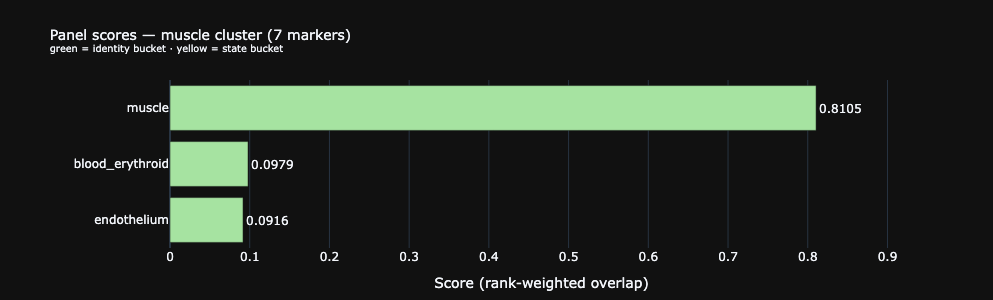

In [8]:
import plotly.graph_objects as go

_COLOURS = {
    zlabel.KIND_IDENTITY: "#A6E3A1",  # green — lineage buckets
    zlabel.KIND_STATE:    "#F9E2AF",  # yellow — state buckets
}

# Show only buckets that scored above zero; everything else stays in the table above.
visible = [s for s in scores if s.score > 0]

fig = go.Figure(
    go.Bar(
        x=[s.score for s in visible],
        y=[s.bucket for s in visible],
        orientation="h",
        marker_color=[_COLOURS[s.kind] for s in visible],
        text=[f"{s.score:.4f}" for s in visible],
        textposition="outside",
        hovertemplate=(
            "<b>%{y}</b><br>score: %{x:.4f}<br>"
            "matched: %{customdata}<extra></extra>"
        ),
        customdata=[
            ", ".join(f"{m.input}(r{m.rank})" for m in s.matched_markers) or "none"
            for s in visible
        ],
    )
)
fig.update_layout(
    title=dict(
        text="Panel scores — muscle cluster (7 markers)<br>"
             "<sup>green = identity bucket · yellow = state bucket</sup>",
        font_size=14,
    ),
    xaxis_title="Score (rank-weighted overlap)",
    xaxis_range=[0, max(s.score for s in visible) * 1.15],
    yaxis={"autorange": "reversed"},
    template="plotly_dark",
    height=max(300, 45 * len(visible) + 100),
    margin=dict(l=170, r=80, t=80, b=50),
)
fig.show()